In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
train_df = pd.read_csv("../../../datasets/application_train.csv")
test_df = pd.read_csv("../../../datasets/application_test.csv")

In [4]:
binary_cols = []

categorical_cols = []

numerical_cols = []

for col in train_df.columns:

    if col == "TARGET":
        continue

    if train_df[col].dtype == "object":

        if train_df[col].nunique() == 2:
            binary_cols.append(col)

        else:
            categorical_cols.append(col)

    else:
        numerical_cols.append(col)

print("Binary:", len(binary_cols))
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Binary: 0
Categorical: 0
Numerical: 121


In [5]:
train_df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [6]:
train_df.dtypes.head(25)

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE                str
CODE_GENDER                       str
FLAG_OWN_CAR                      str
FLAG_OWN_REALTY                   str
CNT_CHILDREN                    int64
AMT_INCOME_TOTAL              float64
AMT_CREDIT                    float64
AMT_ANNUITY                   float64
AMT_GOODS_PRICE               float64
NAME_TYPE_SUITE                   str
NAME_INCOME_TYPE                  str
NAME_EDUCATION_TYPE               str
NAME_FAMILY_STATUS                str
NAME_HOUSING_TYPE                 str
REGION_POPULATION_RELATIVE    float64
DAYS_BIRTH                      int64
DAYS_EMPLOYED                   int64
DAYS_REGISTRATION             float64
DAYS_ID_PUBLISH                 int64
OWN_CAR_AGE                   float64
FLAG_MOBIL                      int64
FLAG_EMP_PHONE                  int64
FLAG_WORK_PHONE                 int64
dtype: object

In [7]:
from pandas.api.types import is_string_dtype, is_numeric_dtype

binary_cols = []
categorical_cols = []
numerical_cols = []

for col in train_df.columns:

    if col == "TARGET":
        continue

    # String columns
    if is_string_dtype(train_df[col]):

        if train_df[col].nunique(dropna=True) == 2:
            binary_cols.append(col)
        else:
            categorical_cols.append(col)

    # Numeric columns
    elif is_numeric_dtype(train_df[col]):
        numerical_cols.append(col)

print(f"Binary Features      : {len(binary_cols)}")
print(f"Categorical Features : {len(categorical_cols)}")
print(f"Numerical Features   : {len(numerical_cols)}")

Binary Features      : 4
Categorical Features : 12
Numerical Features   : 105


In [8]:
print("Binary Features")
print(binary_cols)

Binary Features
['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']


In [9]:
print("Categorical Features")
print(categorical_cols)

Categorical Features
['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [10]:
print("First 20 Numerical Features")
print(numerical_cols[:20])

First 20 Numerical Features
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT']


In [11]:
missing_summary = pd.DataFrame({
    "Missing Percentage": train_df.isnull().mean() * 100,
    "Data Type": train_df.dtypes
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary.head(30)

,Missing Percentage,Data Type
COMMONAREA_AVG,69.872297,float64
COMMONAREA_MODE,69.872297,float64
COMMONAREA_MEDI,69.872297,float64
NONLIVINGAPARTMENTS_MEDI,69.432963,float64
NONLIVINGAPARTMENTS_MODE,69.432963,float64
NONLIVINGAPARTMENTS_AVG,69.432963,float64
FONDKAPREMONT_MODE,68.386172,str
LIVINGAPARTMENTS_AVG,68.354953,float64
LIVINGAPARTMENTS_MEDI,68.354953,float64
LIVINGAPARTMENTS_MODE,68.354953,float64


In [12]:
missing_summary["Missing Category"] = pd.cut(
    missing_summary["Missing Percentage"],
    bins=[-1, 0, 5, 20, 40, 60, 80, 100],
    labels=[
        "No Missing",
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High",
        "Almost Empty"
    ]
)

missing_summary.head(30)

,Missing Percentage,Data Type,Missing Category
COMMONAREA_AVG,69.872297,float64,Very High
COMMONAREA_MODE,69.872297,float64,Very High
COMMONAREA_MEDI,69.872297,float64,Very High
NONLIVINGAPARTMENTS_MEDI,69.432963,float64,Very High
NONLIVINGAPARTMENTS_MODE,69.432963,float64,Very High
NONLIVINGAPARTMENTS_AVG,69.432963,float64,Very High
FONDKAPREMONT_MODE,68.386172,str,Very High
LIVINGAPARTMENTS_AVG,68.354953,float64,Very High
LIVINGAPARTMENTS_MEDI,68.354953,float64,Very High
LIVINGAPARTMENTS_MODE,68.354953,float64,Very High


In [13]:
feature_summary = pd.DataFrame({
    "Feature": train_df.columns,
    "Data Type": train_df.dtypes.astype(str),
    "Missing %": train_df.isnull().mean() * 100,
    "Unique Values": train_df.nunique(),
})

feature_summary.head()

,Feature,Data Type,Missing %,Unique Values
SK_ID_CURR,SK_ID_CURR,int64,0.0,307511
TARGET,TARGET,int64,0.0,2
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,str,0.0,2
CODE_GENDER,CODE_GENDER,str,0.0,3
FLAG_OWN_CAR,FLAG_OWN_CAR,str,0.0,2


In [14]:
def classify_feature(feature):

    if feature == "TARGET":
        return "Target"

    if feature == "SK_ID_CURR":
        return "Identifier"

    if feature in binary_cols:
        return "Binary"

    if feature in categorical_cols:
        return "Categorical"

    return "Numerical"


feature_summary["Feature Type"] = feature_summary["Feature"].apply(classify_feature)

feature_summary.head(20)

,Feature,Data Type,Missing %,Unique Values,Feature Type
SK_ID_CURR,SK_ID_CURR,int64,0.000000,307511,Identifier
TARGET,TARGET,int64,0.000000,2,Target
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,str,0.000000,2,Binary
CODE_GENDER,CODE_GENDER,str,0.000000,3,Categorical
FLAG_OWN_CAR,FLAG_OWN_CAR,str,0.000000,2,Binary
FLAG_OWN_REALTY,FLAG_OWN_REALTY,str,0.000000,2,Binary
CNT_CHILDREN,CNT_CHILDREN,int64,0.000000,15,Numerical
AMT_INCOME_TOTAL,AMT_INCOME_TOTAL,float64,0.000000,2548,Numerical
AMT_CREDIT,AMT_CREDIT,float64,0.000000,5603,Numerical
AMT_ANNUITY,AMT_ANNUITY,float64,0.003902,13672,Numerical


In [15]:
feature_summary.sort_values(
    by="Missing %",
    ascending=False
).head(40)

,Feature,Data Type,Missing %,Unique Values,Feature Type
COMMONAREA_AVG,COMMONAREA_AVG,float64,69.872297,3181,Numerical
COMMONAREA_MODE,COMMONAREA_MODE,float64,69.872297,3128,Numerical
COMMONAREA_MEDI,COMMONAREA_MEDI,float64,69.872297,3202,Numerical
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,float64,69.432963,214,Numerical
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,float64,69.432963,167,Numerical
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,float64,69.432963,386,Numerical
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,str,68.386172,4,Categorical
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,float64,68.354953,1868,Numerical
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,float64,68.354953,1097,Numerical
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,float64,68.354953,736,Numerical


In [16]:
feature_summary.sort_values(
    by="Unique Values"
).head(30)

,Feature,Data Type,Missing %,Unique Values,Feature Type
TARGET,TARGET,int64,0.0,2,Target
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,str,0.0,2,Binary
FLAG_OWN_REALTY,FLAG_OWN_REALTY,str,0.0,2,Binary
FLAG_OWN_CAR,FLAG_OWN_CAR,str,0.0,2,Binary
FLAG_WORK_PHONE,FLAG_WORK_PHONE,int64,0.0,2,Numerical
FLAG_CONT_MOBILE,FLAG_CONT_MOBILE,int64,0.0,2,Numerical
FLAG_EMP_PHONE,FLAG_EMP_PHONE,int64,0.0,2,Numerical
FLAG_MOBIL,FLAG_MOBIL,int64,0.0,2,Numerical
FLAG_PHONE,FLAG_PHONE,int64,0.0,2,Numerical
FLAG_EMAIL,FLAG_EMAIL,int64,0.0,2,Numerical


In [17]:
feature_summary.sort_values(
    by="Unique Values",
    ascending=False
).head(20)

,Feature,Data Type,Missing %,Unique Values,Feature Type
SK_ID_CURR,SK_ID_CURR,int64,0.000000,307511,Identifier
EXT_SOURCE_2,EXT_SOURCE_2,float64,0.214626,119831,Numerical
EXT_SOURCE_1,EXT_SOURCE_1,float64,56.381073,114584,Numerical
DAYS_BIRTH,DAYS_BIRTH,int64,0.000000,17460,Numerical
DAYS_REGISTRATION,DAYS_REGISTRATION,float64,0.000000,15688,Numerical
AMT_ANNUITY,AMT_ANNUITY,float64,0.003902,13672,Numerical
DAYS_EMPLOYED,DAYS_EMPLOYED,int64,0.000000,12574,Numerical
DAYS_ID_PUBLISH,DAYS_ID_PUBLISH,int64,0.000000,6168,Numerical
AMT_CREDIT,AMT_CREDIT,float64,0.000000,5603,Numerical
LIVINGAREA_MODE,LIVINGAREA_MODE,float64,50.193326,5301,Numerical


In [18]:
correlation = train_df.corr(numeric_only=True)["TARGET"].sort_values()

In [19]:
correlation.head(20)

EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
LIVINGAREA_AVG               -0.032997
LIVINGAREA_MEDI              -0.032739
FLOORSMIN_MODE               -0.032698
TOTALAREA_MODE               -0.032596
ELEVATORS_MODE               -0.032131
LIVINGAREA_MODE              -0.030685
AMT_CREDIT                   -0.030369
Name: TARGET, dtype: float64

In [20]:
correlation.tail(20)

OBS_30_CNT_SOCIAL_CIRCLE       0.009131
CNT_FAM_MEMBERS                0.009308
CNT_CHILDREN                   0.019187
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
FLAG_WORK_PHONE                0.028524
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

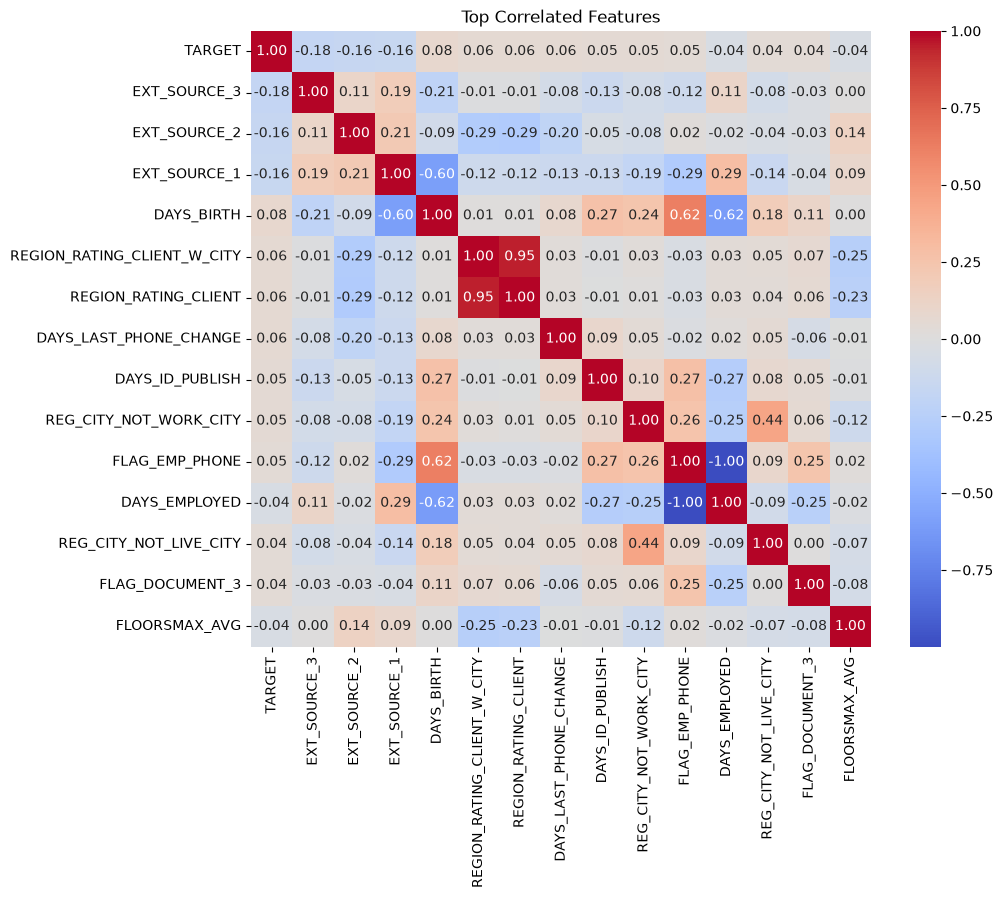

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

top_corr = correlation.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[top_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Correlated Features")

plt.show()

In [22]:
feature_summary.to_csv(
    "../../../docs/feature_summary.csv",
    index=False
)